# Chapter 1: Complex Numbers

Complex numbers sit at the core of quantum mechanics. Every quantum state, every measurement outcome, every interference pattern depends on them. This chapter builds the full toolkit, from the algebraic foundations through the geometry of the complex plane, that the rest of the book requires.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cmath

# Convenience: display settings
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams['figure.dpi'] = 100
np.set_printoptions(precision=6, suppress=True)

## 1.1 Basic Definitions

Try solving $x^2 + 1 = 0$. Every real number squared is non-negative, so adding 1 pushes the result strictly positive. No real solution exists.

Mathematics handles this by postulating: there is a number whose square is $-1$. Call it $i$.

$$i^2 = -1 \qquad \text{or equivalently} \qquad i = \sqrt{-1}$$

Aside from this one special property, $i$ obeys the same rules as any ordinary number. From $i$ we can build all the powers:

| Power | Value |
|-------|-------|
| $i^0$ | $1$ |
| $i^1$ | $i$ |
| $i^2$ | $-1$ |
| $i^3$ | $-i$ |
| $i^4$ | $1$ |

The pattern cycles with period 4. For any integer $n$: $i^n = i^{n \bmod 4}$.

In [2]:
# Quick verification: powers of i cycle with period 4
for n in range(9):
    print(f"i^{n} = {1j**n:.0f}")

i^0 = 1+0j
i^1 = 0+1j
i^2 = -1+0j
i^3 = -0-1j
i^4 = 1+0j
i^5 = 0+1j
i^6 = -1+0j
i^7 = -0-1j
i^8 = 1+0j


A **complex number** combines a real part and an imaginary part:

$$z = a + bi$$

where $a, b \in \mathbb{R}$. The number $a$ is the **real part** (written $\text{Re}(z)$) and $b$ is the **imaginary part** (written $\text{Im}(z)$). The set of all complex numbers is denoted $\mathbb{C}$.

Every real number is a complex number with $b = 0$. And $i$ itself is the complex number $0 + 1 \cdot i$.

**Exercise 1.1.1.** Verify that the equation $x^4 + 2x^2 + 1 = 0$ has no solution among the real numbers. (Hint: factor the polynomial.)

In [3]:
# Exercise 1.1.1 — Solution
# Factor: x^4 + 2x^2 + 1 = (x^2 + 1)^2
# Setting (x^2 + 1)^2 = 0 requires x^2 + 1 = 0, i.e. x^2 = -1.
# No real number has a negative square, so no real solution exists.

# We can verify numerically that the roots are purely imaginary:
coeffs = [1, 0, 2, 0, 1]  # x^4 + 0x^3 + 2x^2 + 0x + 1
roots = np.roots(coeffs)
print("Roots:", roots)
print("All roots are purely imaginary (real parts ≈ 0).")

Roots: [-0.+1.j -0.-1.j  0.+1.j  0.-1.j]
All roots are purely imaginary (real parts ≈ 0).


**Exercise 1.1.2.** Compute $(-1 + \sqrt{3}\,i)^3$ by hand and verify.

In [4]:
# Exercise 1.1.2 — Solution
# Let z = -1 + sqrt(3)*i
z = -1 + np.sqrt(3)*1j

# Step by step:
# z^2 = (-1 + sqrt(3)i)^2 = 1 - 2*sqrt(3)*i + 3*i^2 = 1 - 2*sqrt(3)*i - 3 = -2 - 2*sqrt(3)*i
z2 = z**2
print(f"z^2 = {z2:.6f}")

# z^3 = z^2 * z = (-2 - 2*sqrt(3)*i)(-1 + sqrt(3)*i)
#      = 2 - 2*sqrt(3)*i + 2*sqrt(3)*i - 2*3*i^2
#      = 2 + 6 = 8
z3 = z**3
print(f"z^3 = {z3:.6f}")
print(f"z^3 is real and equals 8: {np.isclose(z3, 8)}")

z^2 = -2.000000-3.464102j
z^3 = 8.000000+0.000000j
z^3 is real and equals 8: True


**Exercise 1.1.3.** Verify that $(a + bi)(c + di) = (ac - bd) + (ad + bc)i$ by expanding and using $i^2 = -1$.

**Solution (Exercise 1.1.3).** Expand directly:

$$(a + bi)(c + di) = ac + adi + bci + bdi^2 = ac + (ad + bc)i + bd(-1) = (ac - bd) + (ad + bc)i \quad \square$$

**Exercise 1.1.4.** Verify that the product of a complex number $z = a + bi$ with its conjugate $\bar{z} = a - bi$ is a non-negative real number: $z \bar{z} = a^2 + b^2$.

In [5]:
# Exercise 1.1.4 — Solution
# z * conj(z) = (a + bi)(a - bi) = a^2 - (bi)^2 = a^2 - b^2*i^2 = a^2 + b^2
# This is always real and non-negative.

# Numerical check with a specific example:
z = 3 + 4j
product = z * z.conjugate()
print(f"z = {z}")
print(f"z * conj(z) = {product}")
print(f"a^2 + b^2 = {3**2 + 4**2}")
print(f"Match: {np.isclose(product, 3**2 + 4**2)}")

z = (3+4j)
z * conj(z) = (25+0j)
a^2 + b^2 = 25
Match: True


### Programming Drill 1.1.1

Write a function that takes two complex numbers and returns their sum and product.

In [6]:
# Programming Drill 1.1.1

def complex_sum_product(z1, z2):
    """Return the sum and product of two complex numbers.
    
    Each input is a tuple (a, b) representing a + bi.
    Returns two tuples: the sum and the product.
    """
    a1, b1 = z1
    a2, b2 = z2
    
    # Sum: (a1 + a2) + (b1 + b2)i
    s = (a1 + a2, b1 + b2)
    
    # Product: (a1*a2 - b1*b2) + (a1*b2 + b1*a2)i
    p = (a1*a2 - b1*b2, a1*b2 + b1*a2)
    
    return s, p

# Test
z1 = (3, 2)   # 3 + 2i
z2 = (1, -4)  # 1 - 4i
s, p = complex_sum_product(z1, z2)
print(f"z1 = {z1[0]} + {z1[1]}i")
print(f"z2 = {z2[0]} + {z2[1]}i")
print(f"Sum:     {s[0]} + {s[1]}i")
print(f"Product: {p[0]} + {p[1]}i")

# Verify against Python's built-in complex
z1c, z2c = complex(*z1), complex(*z2)
assert complex(*s) == z1c + z2c
assert complex(*p) == z1c * z2c
print("\nVerified against Python built-in complex type.")

z1 = 3 + 2i
z2 = 1 + -4i
Sum:     4 + -2i
Product: 11 + -10i

Verified against Python built-in complex type.


## 1.2 The Algebra of Complex Numbers

We can make the definition more rigorous by treating complex numbers as ordered pairs of real numbers. Define $\mathbb{C}$ as the set of all pairs $(a, b)$ where $a, b \in \mathbb{R}$, equipped with specific rules for arithmetic.

This ordered-pair viewpoint strips away the mystery of "imaginary" numbers: a complex number is just two real numbers packaged together, with multiplication defined in a particular (and useful) way.

### Arithmetic Operations

For $z_1 = (a_1, b_1)$ and $z_2 = (a_2, b_2)$:

**Addition:**
$$(a_1, b_1) + (a_2, b_2) = (a_1 + a_2,\; b_1 + b_2)$$

**Subtraction:**
$$(a_1, b_1) - (a_2, b_2) = (a_1 - a_2,\; b_1 - b_2)$$

**Multiplication:**
$$(a_1, b_1) \times (a_2, b_2) = (a_1 a_2 - b_1 b_2,\; a_1 b_2 + b_1 a_2)$$

**Division** (when $z_2 \neq 0$):
$$\frac{(a_1, b_1)}{(a_2, b_2)} = \left(\frac{a_1 a_2 + b_1 b_2}{a_2^2 + b_2^2},\; \frac{b_1 a_2 - a_1 b_2}{a_2^2 + b_2^2}\right)$$

The division formula comes from multiplying numerator and denominator by the conjugate of $z_2$.

### Modulus and Conjugate

The **conjugate** of $z = (a, b)$ is $\bar{z} = (a, -b)$. Geometrically, it reflects $z$ across the real axis.

The **modulus** (or absolute value) of $z = (a, b)$ is:
$$|z| = \sqrt{a^2 + b^2}$$

This is the distance from $z$ to the origin in the complex plane. Two key properties:
- $z \bar{z} = |z|^2$
- $|z| \geq 0$, with equality only when $z = 0$

### Field Properties

$\mathbb{C}$ with these operations forms a **field**. The essential properties:

1. **Commutativity:** $z_1 + z_2 = z_2 + z_1$ and $z_1 z_2 = z_2 z_1$
2. **Associativity:** $(z_1 + z_2) + z_3 = z_1 + (z_2 + z_3)$ and $(z_1 z_2) z_3 = z_1 (z_2 z_3)$
3. **Distributivity:** $z_1(z_2 + z_3) = z_1 z_2 + z_1 z_3$
4. **Additive identity:** $(0, 0)$
5. **Multiplicative identity:** $(1, 0)$
6. **Additive inverse:** $-z = (-a, -b)$
7. **Multiplicative inverse** (for $z \neq 0$): $z^{-1} = \bar{z}/|z|^2$

The real numbers embed naturally: $a \in \mathbb{R}$ corresponds to $(a, 0) \in \mathbb{C}$.

### Triangle Inequality

For any two complex numbers:

$$|z_1 + z_2| \leq |z_1| + |z_2|$$

The name comes from geometry: the length of one side of a triangle never exceeds the sum of the other two.

### Programming Drill 1.2.1

Extend the previous drill to include subtraction, division, modulus, and conjugate.

In [7]:
# Programming Drill 1.2.1 — Full complex arithmetic library

def c_add(z1, z2):
    """Add two complex numbers represented as (a, b) tuples."""
    return (z1[0] + z2[0], z1[1] + z2[1])

def c_sub(z1, z2):
    """Subtract z2 from z1."""
    return (z1[0] - z2[0], z1[1] - z2[1])

def c_mul(z1, z2):
    """Multiply two complex numbers."""
    a1, b1 = z1
    a2, b2 = z2
    return (a1*a2 - b1*b2, a1*b2 + b1*a2)

def c_div(z1, z2):
    """Divide z1 by z2."""
    a1, b1 = z1
    a2, b2 = z2
    denom = a2**2 + b2**2
    if denom == 0:
        raise ZeroDivisionError("Division by zero")
    return ((a1*a2 + b1*b2) / denom, (b1*a2 - a1*b2) / denom)

def c_mod(z):
    """Return the modulus |z|."""
    return (z[0]**2 + z[1]**2) ** 0.5

def c_conj(z):
    """Return the conjugate of z."""
    return (z[0], -z[1])

# ---------- Tests ----------
z1 = (3, 2)
z2 = (1, -4)

print(f"z1 = {z1[0]} + {z1[1]}i")
print(f"z2 = {z2[0]} + {z2[1]}i")
print(f"Add:  {c_add(z1, z2)}")
print(f"Sub:  {c_sub(z1, z2)}")
print(f"Mul:  {c_mul(z1, z2)}")
print(f"Div:  {c_div(z1, z2)}")
print(f"|z1|: {c_mod(z1):.6f}")
print(f"Conj(z1): {c_conj(z1)}")

# Verify against Python built-ins
Z1, Z2 = complex(*z1), complex(*z2)
assert np.isclose(complex(*c_add(z1, z2)), Z1 + Z2)
assert np.isclose(complex(*c_sub(z1, z2)), Z1 - Z2)
assert np.isclose(complex(*c_mul(z1, z2)), Z1 * Z2)
assert np.isclose(complex(*c_div(z1, z2)), Z1 / Z2)
assert np.isclose(c_mod(z1), abs(Z1))
assert np.isclose(complex(*c_conj(z1)), Z1.conjugate())
print("\nAll operations verified.")

z1 = 3 + 2i
z2 = 1 + -4i
Add:  (4, -2)
Sub:  (2, 6)
Mul:  (11, -10)
Div:  (-0.29411764705882354, 0.8235294117647058)
|z1|: 3.605551
Conj(z1): (3, -2)

All operations verified.


**Exercise 1.2.1.** Compute $(3, 2) + (1, -4)$.

In [8]:
# Exercise 1.2.1 — Solution
# (3, 2) + (1, -4) = (3+1, 2+(-4)) = (4, -2)
result = c_add((3, 2), (1, -4))
print(f"(3,2) + (1,-4) = {result}")

(3,2) + (1,-4) = (4, -2)


**Exercise 1.2.2.** Compute $(3, 2) \times (1, -4)$.

In [9]:
# Exercise 1.2.2 — Solution
# (3,2) x (1,-4) = (3*1 - 2*(-4), 3*(-4) + 2*1) = (3+8, -12+2) = (11, -10)
result = c_mul((3, 2), (1, -4))
print(f"(3,2) × (1,-4) = {result}")

(3,2) × (1,-4) = (11, -10)


**Exercise 1.2.3.** Compute $(3, 2) - (1, -4)$.

In [10]:
# Exercise 1.2.3 — Solution
# (3,2) - (1,-4) = (3-1, 2-(-4)) = (2, 6)
result = c_sub((3, 2), (1, -4))
print(f"(3,2) - (1,-4) = {result}")

(3,2) - (1,-4) = (2, 6)


**Exercise 1.2.4.** Compute $(3, 2) / (1, -4)$.

In [11]:
# Exercise 1.2.4 — Solution
# (3,2)/(1,-4):
# denom = 1^2 + (-4)^2 = 17
# real part: (3*1 + 2*(-4))/17 = (3-8)/17 = -5/17
# imag part: (2*1 - 3*(-4))/17 = (2+12)/17 = 14/17
result = c_div((3, 2), (1, -4))
print(f"(3,2) / (1,-4) = ({result[0]:.6f}, {result[1]:.6f})")
print(f"Exact: (-5/17, 14/17) = ({-5/17:.6f}, {14/17:.6f})")

(3,2) / (1,-4) = (-0.294118, 0.823529)
Exact: (-5/17, 14/17) = (-0.294118, 0.823529)


**Exercise 1.2.5.** Compute the modulus of $z = (3, -4)$.

In [12]:
# Exercise 1.2.5 — Solution
# |z| = sqrt(3^2 + (-4)^2) = sqrt(9 + 16) = sqrt(25) = 5
z = (3, -4)
print(f"|(3, -4)| = {c_mod(z)}")

|(3, -4)| = 5.0


**Exercise 1.2.6.** Compute the conjugate of $(3, -4)$.

In [13]:
# Exercise 1.2.6 — Solution
# conj(3, -4) = (3, 4)
z = (3, -4)
print(f"Conjugate of (3, -4) = {c_conj(z)}")

Conjugate of (3, -4) = (3, 4)


**Exercise 1.2.7.** Verify that multiplication of complex numbers is commutative: $z_1 z_2 = z_2 z_1$.

**Solution (Exercise 1.2.7).** Let $z_1 = (a_1, b_1)$ and $z_2 = (a_2, b_2)$.

$$z_1 z_2 = (a_1 a_2 - b_1 b_2,\; a_1 b_2 + b_1 a_2)$$
$$z_2 z_1 = (a_2 a_1 - b_2 b_1,\; a_2 b_1 + b_2 a_1)$$

Since real multiplication is commutative ($a_1 a_2 = a_2 a_1$, etc.), these are identical. $\square$

**Exercise 1.2.8.** Verify that multiplication distributes over addition: $z_1(z_2 + z_3) = z_1 z_2 + z_1 z_3$.

**Solution (Exercise 1.2.8).** Let $z_j = (a_j, b_j)$ for $j = 1, 2, 3$.

Left side: $z_1(z_2 + z_3) = (a_1, b_1)(a_2 + a_3, b_2 + b_3)$

$$= \bigl(a_1(a_2+a_3) - b_1(b_2+b_3),\; a_1(b_2+b_3) + b_1(a_2+a_3)\bigr)$$

$$= (a_1 a_2 + a_1 a_3 - b_1 b_2 - b_1 b_3,\; a_1 b_2 + a_1 b_3 + b_1 a_2 + b_1 a_3)$$

Right side: $z_1 z_2 + z_1 z_3$

$$= (a_1 a_2 - b_1 b_2, a_1 b_2 + b_1 a_2) + (a_1 a_3 - b_1 b_3, a_1 b_3 + b_1 a_3)$$

$$= (a_1 a_2 + a_1 a_3 - b_1 b_2 - b_1 b_3,\; a_1 b_2 + b_1 a_2 + a_1 b_3 + b_1 a_3)$$

These are equal. $\square$

**Exercise 1.2.9.** Verify that $(a, b)(a, -b) = (a^2 + b^2, 0)$.

In [14]:
# Exercise 1.2.9 — Solution
# (a,b)(a,-b) = (a*a - b*(-b), a*(-b) + b*a) = (a^2 + b^2, -ab + ab) = (a^2 + b^2, 0)
# Verified algebraically above. Numerical check:
a, b = 5, 7
z = (a, b)
zbar = c_conj(z)
product = c_mul(z, zbar)
print(f"({a},{b}) * ({a},{-b}) = {product}")
print(f"a^2 + b^2 = {a**2 + b**2}")
print(f"Match: {product == (a**2 + b**2, 0)}")

(5,7) * (5,-7) = (74, 0)
a^2 + b^2 = 74
Match: True


**Exercise 1.2.10.** Verify the multiplicative inverse: for $z = (a, b) \neq (0,0)$,

$$z^{-1} = \left(\frac{a}{a^2+b^2},\; \frac{-b}{a^2+b^2}\right)$$

satisfies $z \cdot z^{-1} = (1, 0)$.

In [15]:
# Exercise 1.2.10 — Solution
a, b = 3, 4
z = (a, b)
mod_sq = a**2 + b**2
z_inv = (a / mod_sq, -b / mod_sq)
product = c_mul(z, z_inv)
print(f"z = {z}")
print(f"z^(-1) = ({z_inv[0]:.6f}, {z_inv[1]:.6f})")
print(f"z * z^(-1) = ({product[0]:.10f}, {product[1]:.10f})")
print(f"Equals (1,0): {np.isclose(product[0], 1) and np.isclose(product[1], 0)}")

z = (3, 4)
z^(-1) = (0.120000, -0.160000)
z * z^(-1) = (1.0000000000, 0.0000000000)
Equals (1,0): True


**Exercise 1.2.11.** Verify the modulus respects multiplication: $|z_1 z_2| = |z_1| \cdot |z_2|$.

In [16]:
# Exercise 1.2.11 — Solution
# |z1 z2|^2 = (z1 z2) * conj(z1 z2) = z1 z2 conj(z2) conj(z1)
#           = z1 |z2|^2 conj(z1) = |z1|^2 |z2|^2
# Taking square roots: |z1 z2| = |z1| |z2|

# Numerical verification:
z1 = (3, 2)
z2 = (1, -4)
prod = c_mul(z1, z2)
lhs = c_mod(prod)
rhs = c_mod(z1) * c_mod(z2)
print(f"|z1 * z2| = {lhs:.6f}")
print(f"|z1| * |z2| = {rhs:.6f}")
print(f"Equal: {np.isclose(lhs, rhs)}")

|z1 * z2| = 14.866069
|z1| * |z2| = 14.866069
Equal: True


**Exercise 1.2.12.** Verify the triangle inequality: $|z_1 + z_2| \leq |z_1| + |z_2|$.

In [17]:
# Exercise 1.2.12 — Solution
# Proof sketch:
# |z1 + z2|^2 = (z1+z2)*conj(z1+z2) = |z1|^2 + z1*conj(z2) + conj(z1)*z2 + |z2|^2
# The middle terms sum to 2*Re(z1*conj(z2)), which is <= 2|z1||z2|.
# So |z1+z2|^2 <= |z1|^2 + 2|z1||z2| + |z2|^2 = (|z1| + |z2|)^2.

# Numerical verification with several examples:
test_pairs = [
    ((3, 2), (1, -4)),
    ((1, 1), (-1, 1)),
    ((0, 5), (3, 0)),
    ((-2, 3), (2, -3)),  # This one gives equality (opposite directions)
]

for z1, z2 in test_pairs:
    s = c_add(z1, z2)
    lhs = c_mod(s)
    rhs = c_mod(z1) + c_mod(z2)
    print(f"|{z1} + {z2}| = {lhs:.4f} <= {rhs:.4f}  ✓" if lhs <= rhs + 1e-10 else "FAIL")

|(3, 2) + (1, -4)| = 4.4721 <= 7.7287  ✓
|(1, 1) + (-1, 1)| = 2.0000 <= 2.8284  ✓
|(0, 5) + (3, 0)| = 5.8310 <= 8.0000  ✓
|(-2, 3) + (2, -3)| = 0.0000 <= 7.2111  ✓


## 1.3 The Geometry of Complex Numbers

Every complex number $z = a + bi$ corresponds to a point $(a, b)$ in the plane. Plot the real part on the horizontal axis, the imaginary part on the vertical axis, and you get the **complex plane** (also called the Argand plane after Jean-Robert Argand, who published the idea in 1806).

This geometric view transforms abstract algebra into something you can see. Addition becomes vector addition. The modulus becomes distance. And multiplication, as we will discover, becomes rotation and scaling.

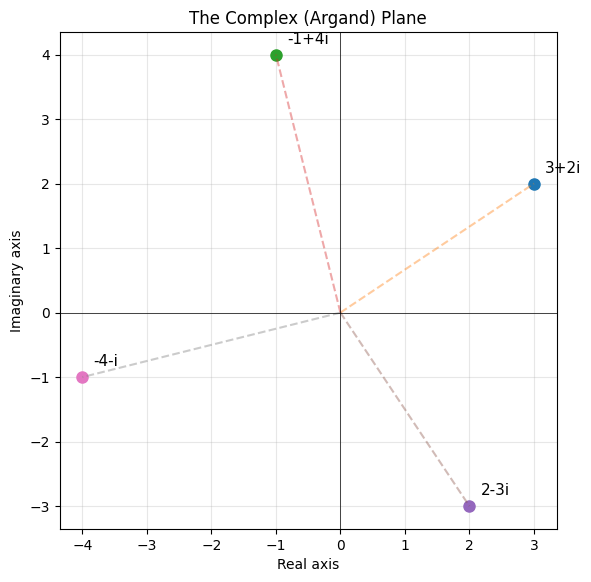

In [18]:
# Plotting complex numbers in the Argand plane
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

points = {
    '3+2i': 3+2j,
    '-1+4i': -1+4j,
    '2-3i': 2-3j,
    '-4-i': -4-1j,
}

for label, z in points.items():
    ax.plot(z.real, z.imag, 'o', markersize=8)
    ax.annotate(label, (z.real, z.imag), textcoords='offset points',
               xytext=(8, 8), fontsize=11)
    ax.plot([0, z.real], [0, z.imag], '--', alpha=0.4)

ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Real axis')
ax.set_ylabel('Imaginary axis')
ax.set_title('The Complex (Argand) Plane')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Polar Representation

Any point in the plane can be described by its distance from the origin and its angle from the positive real axis, instead of by its Cartesian coordinates. For a complex number $z$:

- **Modulus** $r = |z| = \sqrt{a^2 + b^2}$: the distance from the origin
- **Argument** $\theta = \arg(z) = \arctan(b/a)$: the angle (measured counterclockwise from the positive real axis)

The conversion formulas:

$$a = r\cos\theta, \qquad b = r\sin\theta$$
$$z = r(\cos\theta + i\sin\theta)$$

### Multiplication in Polar Form

Polar coordinates reveal the geometric meaning of complex multiplication. If $z_1 = r_1(\cos\theta_1 + i\sin\theta_1)$ and $z_2 = r_2(\cos\theta_2 + i\sin\theta_2)$, then:

$$z_1 z_2 = r_1 r_2 \bigl(\cos(\theta_1 + \theta_2) + i\sin(\theta_1 + \theta_2)\bigr)$$

Multiplying two complex numbers **multiplies their moduli** and **adds their arguments**. In geometric terms: scale by $r_2$, rotate by $\theta_2$.

Division works in reverse: divide the moduli, subtract the arguments.

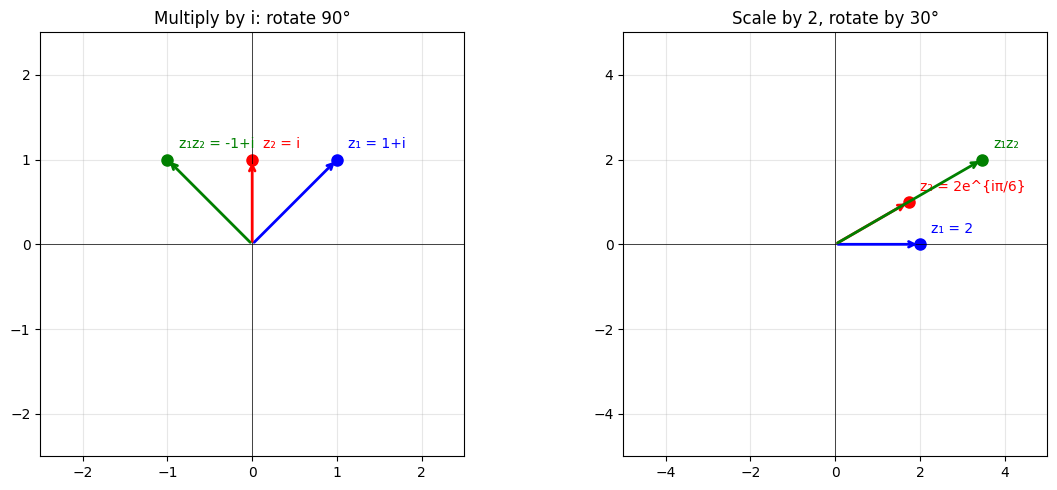

In [19]:
# Visualizing multiplication as rotation + scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

z1 = 1 + 1j  # r=sqrt(2), theta=pi/4
z2 = 0 + 1j  # r=1, theta=pi/2 (pure rotation by 90 degrees)
z3 = z1 * z2

# Left plot: multiplication by i (rotation by 90°)
ax = axes[0]
for z, label, color in [(z1, 'z₁ = 1+i', 'blue'), (z2, 'z₂ = i', 'red'), (z3, 'z₁z₂ = -1+i', 'green')]:
    ax.annotate('', xy=(z.real, z.imag), xytext=(0, 0),
               arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.plot(z.real, z.imag, 'o', color=color, markersize=8)
    ax.annotate(label, (z.real, z.imag), textcoords='offset points',
               xytext=(8, 8), fontsize=10, color=color)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)
ax.set_title('Multiply by i: rotate 90°')

# Right plot: multiplication by 2*exp(i*pi/6)
ax = axes[1]
z1 = 2 + 0j
z2 = 2 * np.exp(1j * np.pi/6)  # r=2, theta=30°
z3 = z1 * z2
for z, label, color in [(z1, 'z₁ = 2', 'blue'), (z2, 'z₂ = 2e^{iπ/6}', 'red'), (z3, 'z₁z₂', 'green')]:
    ax.annotate('', xy=(z.real, z.imag), xytext=(0, 0),
               arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.plot(z.real, z.imag, 'o', color=color, markersize=8)
    ax.annotate(label, (z.real, z.imag), textcoords='offset points',
               xytext=(8, 8), fontsize=10, color=color)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)
ax.set_title('Scale by 2, rotate by 30°')

plt.tight_layout()
plt.show()

### Powers and Roots

Repeated multiplication in polar form gives us powers directly. If $z = r(\cos\theta + i\sin\theta)$:

$$z^n = r^n(\cos(n\theta) + i\sin(n\theta))$$

This is **De Moivre's formula**, and it makes computing powers trivial in polar form.

For roots, we go in reverse. The $n$th roots of a complex number $z = r e^{i\theta}$ are:

$$z^{1/n} = r^{1/n} \exp\left(i\,\frac{\theta + 2\pi k}{n}\right), \qquad k = 0, 1, \ldots, n-1$$

There are always exactly $n$ distinct $n$th roots, equally spaced around a circle of radius $r^{1/n}$.

### Roots of Unity

The $n$th **roots of unity** are the $n$ solutions to $z^n = 1$:

$$\omega_k = \exp\left(\frac{2\pi i k}{n}\right), \qquad k = 0, 1, \ldots, n-1$$

They form a regular $n$-gon inscribed in the unit circle. The primitive $n$th root of unity $\omega = e^{2\pi i/n}$ generates all the others: $\omega^0, \omega^1, \ldots, \omega^{n-1}$.

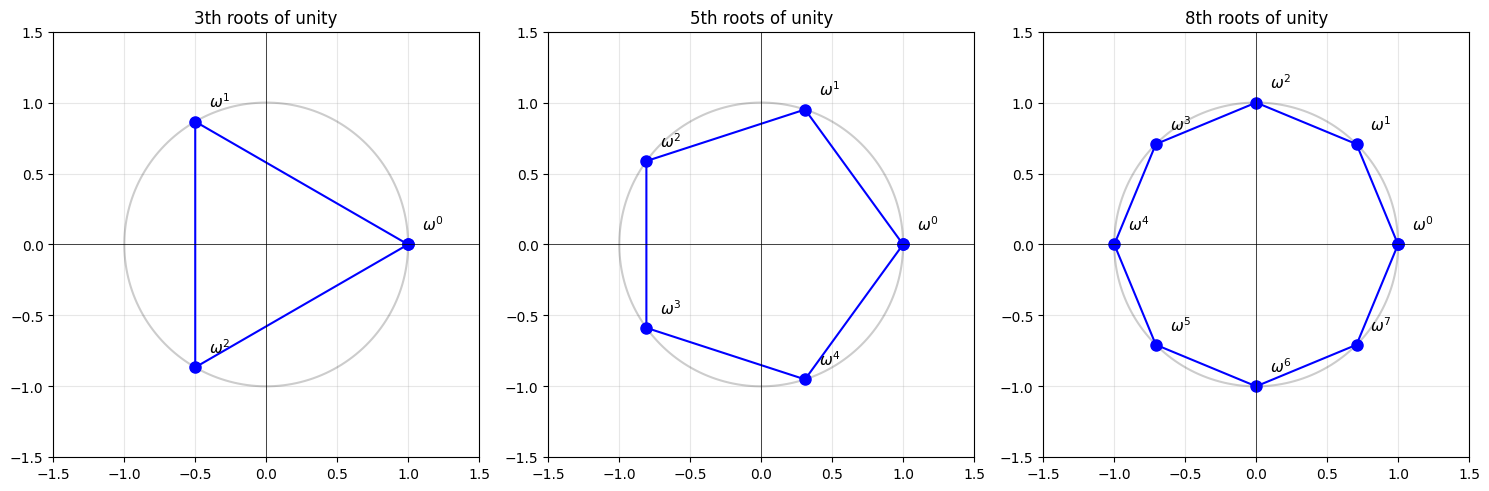

In [20]:
# Plotting the nth roots of unity
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, n in enumerate([3, 5, 8]):
    ax = axes[idx]
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k-', alpha=0.2)  # unit circle
    
    roots = [np.exp(2j * np.pi * k / n) for k in range(n)]
    xs = [z.real for z in roots] + [roots[0].real]
    ys = [z.imag for z in roots] + [roots[0].imag]
    ax.plot(xs, ys, 'b-o', markersize=8)
    
    for k, z in enumerate(roots):
        ax.annotate(f'$\\omega^{k}$', (z.real, z.imag),
                   textcoords='offset points', xytext=(10, 10), fontsize=11)
    
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)
    ax.set_title(f'{n}th roots of unity')

plt.tight_layout()
plt.show()

### Euler's Formula and the Exponential Form

One of the most beautiful results in mathematics connects the exponential function to trigonometry:

$$e^{i\theta} = \cos\theta + i\sin\theta$$

This is **Euler's formula**. Setting $\theta = \pi$ yields the celebrated identity $e^{i\pi} + 1 = 0$, which links five fundamental constants in a single equation.

Euler's formula gives us the compact **exponential form** of a complex number:

$$z = r e^{i\theta}$$

De Moivre's formula is a direct consequence:

$$(e^{i\theta})^n = e^{in\theta}$$

which is just the law of exponents applied to complex exponentials.

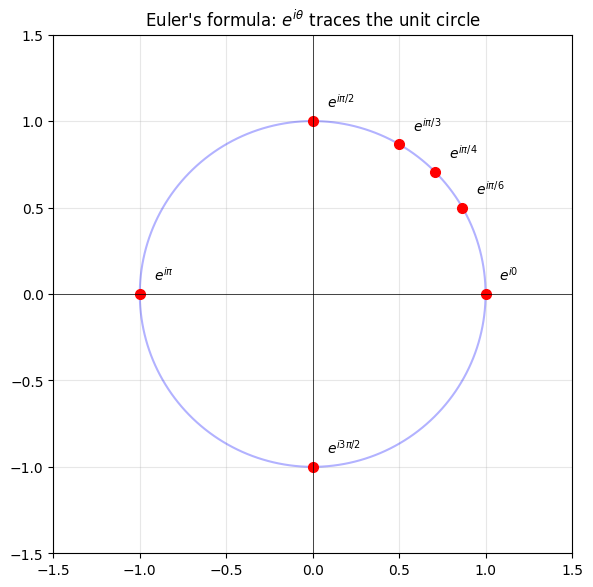

In [21]:
# Euler's formula: visualize e^{i*theta} tracing the unit circle
fig, ax = plt.subplots(figsize=(6, 6))

theta = np.linspace(0, 2*np.pi, 200)
circle = np.exp(1j * theta)
ax.plot(circle.real, circle.imag, 'b-', alpha=0.3, label='Unit circle')

# Mark some special angles
special = {
    '0': 0,
    'π/6': np.pi/6,
    'π/4': np.pi/4,
    'π/3': np.pi/3,
    'π/2': np.pi/2,
    'π': np.pi,
    '3π/2': 3*np.pi/2,
}

for label, t in special.items():
    z = np.exp(1j * t)
    ax.plot(z.real, z.imag, 'ro', markersize=7)
    ax.annotate(f'$e^{{i{label}}}$', (z.real, z.imag),
               textcoords='offset points', xytext=(10, 10), fontsize=10)

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)
ax.set_title("Euler's formula: $e^{i\\theta}$ traces the unit circle")
plt.tight_layout()
plt.show()

### Mobius Transformations

A **Mobius transformation** (also called a fractional linear transformation) is a function of the form:

$$f(z) = \frac{az + b}{cz + d}$$

where $a, b, c, d \in \mathbb{C}$ and $ad - bc \neq 0$. These transformations map the extended complex plane (including a point at infinity) to itself, and they form a group under composition.

Mobius transformations preserve angles and map circles and lines to circles and lines. They are the most general conformal maps of the Riemann sphere, and they appear throughout mathematics and physics.

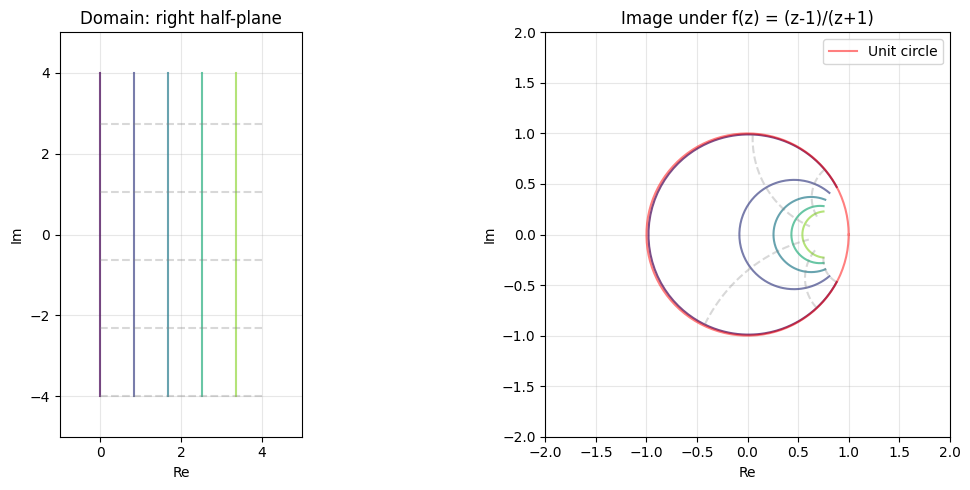

In [22]:
# Mobius transformation example
# f(z) = (z - 1) / (z + 1) maps the right half-plane to the unit disk

def mobius(z, a, b, c, d):
    """Compute the Mobius transformation (az+b)/(cz+d)."""
    return (a*z + b) / (c*z + d)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create a grid of points in the right half-plane
t = np.linspace(0.01, 4, 20)
s = np.linspace(-4, 4, 20)

# Plot vertical lines and their images
ax1, ax2 = axes
colors = plt.cm.viridis(np.linspace(0, 1, len(t)))

for i, x0 in enumerate(t[::4]):
    # Vertical line at Re(z) = x0
    zs = x0 + 1j * np.linspace(-4, 4, 200)
    ws = mobius(zs, 1, -1, 1, 1)  # (z-1)/(z+1)
    ax1.plot(zs.real, zs.imag, '-', color=colors[i*4], alpha=0.7)
    ax2.plot(ws.real, ws.imag, '-', color=colors[i*4], alpha=0.7)

for i, y0 in enumerate(s[::4]):
    # Horizontal line at Im(z) = y0
    zs = np.linspace(0.01, 4, 200) + 1j * y0
    ws = mobius(zs, 1, -1, 1, 1)
    ax1.plot(zs.real, zs.imag, '--', color='gray', alpha=0.3)
    ax2.plot(ws.real, ws.imag, '--', color='gray', alpha=0.3)

# Unit circle on the image
theta = np.linspace(0, 2*np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), 'r-', alpha=0.5, label='Unit circle')

ax1.set_xlim(-1, 5); ax1.set_ylim(-5, 5)
ax1.set_aspect('equal'); ax1.grid(True, alpha=0.3)
ax1.set_title('Domain: right half-plane')
ax1.set_xlabel('Re'); ax1.set_ylabel('Im')

ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2)
ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)
ax2.set_title('Image under f(z) = (z-1)/(z+1)')
ax2.set_xlabel('Re'); ax2.set_ylabel('Im')
ax2.legend()

plt.tight_layout()
plt.show()

### Programming Drill 1.3.1

Write functions to convert between Cartesian and polar representations.

In [23]:
# Programming Drill 1.3.1 — Cartesian ↔ Polar conversion

def cartesian_to_polar(z):
    """Convert (a, b) Cartesian to (r, theta) polar."""
    a, b = z
    r = (a**2 + b**2) ** 0.5
    theta = np.arctan2(b, a)
    return (r, theta)

def polar_to_cartesian(p):
    """Convert (r, theta) polar to (a, b) Cartesian."""
    r, theta = p
    return (r * np.cos(theta), r * np.sin(theta))

# Test round-trips
test_points = [(3, 4), (-1, 1), (0, 5), (-2, -3)]
for z in test_points:
    polar = cartesian_to_polar(z)
    back = polar_to_cartesian(polar)
    print(f"Cartesian {z} -> Polar (r={polar[0]:.4f}, θ={np.degrees(polar[1]):.1f}°) -> Back ({back[0]:.4f}, {back[1]:.4f})")
    assert np.isclose(z[0], back[0]) and np.isclose(z[1], back[1])

print("\nAll round-trip conversions verified.")

Cartesian (3, 4) -> Polar (r=5.0000, θ=53.1°) -> Back (3.0000, 4.0000)
Cartesian (-1, 1) -> Polar (r=1.4142, θ=135.0°) -> Back (-1.0000, 1.0000)
Cartesian (0, 5) -> Polar (r=5.0000, θ=90.0°) -> Back (0.0000, 5.0000)
Cartesian (-2, -3) -> Polar (r=3.6056, θ=-123.7°) -> Back (-2.0000, -3.0000)

All round-trip conversions verified.


### Programming Drill 1.3.2

Write a program that draws a given shape on the complex plane and then multiplies every point by a complex number, showing the result.

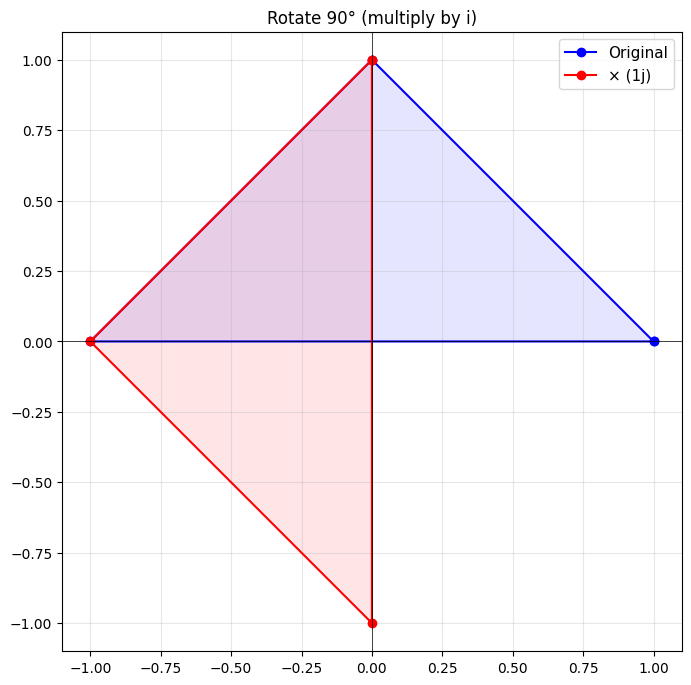

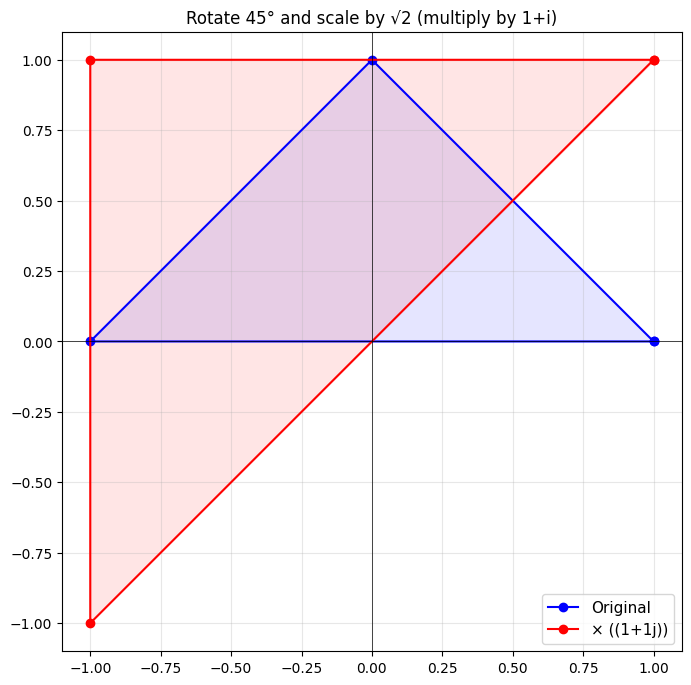

In [24]:
# Programming Drill 1.3.2 — Multiply a drawing by a complex number

def plot_complex_transform(points, multiplier, title=''):
    """Plot a shape (list of complex numbers) and its image under
    multiplication by `multiplier`."""
    original = np.array(points)
    transformed = original * multiplier
    
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # Plot original
    ox = np.append(original.real, original[0].real)
    oy = np.append(original.imag, original[0].imag)
    ax.plot(ox, oy, 'b-o', label='Original', markersize=6)
    ax.fill(original.real, original.imag, alpha=0.1, color='blue')
    
    # Plot transformed
    tx = np.append(transformed.real, transformed[0].real)
    ty = np.append(transformed.imag, transformed[0].imag)
    ax.plot(tx, ty, 'r-o', label=f'× ({multiplier})', markersize=6)
    ax.fill(transformed.real, transformed.imag, alpha=0.1, color='red')
    
    ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    ax.set_title(title or f'Multiplication by {multiplier}')
    plt.tight_layout()
    plt.show()

# A triangle in the complex plane
triangle = [1+0j, 0+1j, -1+0j]

# Multiply by i (rotate 90°)
plot_complex_transform(triangle, 1j, 'Rotate 90° (multiply by i)')

# Multiply by 1+i (rotate 45° and scale by sqrt(2))
plot_complex_transform(triangle, 1+1j, 'Rotate 45° and scale by √2 (multiply by 1+i)')

### Programming Drill 1.3.3

Implement full polar arithmetic: multiplication, division, and conversion in polar form.

In [25]:
# Programming Drill 1.3.3 — Full polar operations

def polar_mul(p1, p2):
    """Multiply two complex numbers in polar form (r, theta)."""
    r1, t1 = p1
    r2, t2 = p2
    return (r1 * r2, t1 + t2)

def polar_div(p1, p2):
    """Divide p1 by p2 in polar form."""
    r1, t1 = p1
    r2, t2 = p2
    if r2 == 0:
        raise ZeroDivisionError("Division by zero")
    return (r1 / r2, t1 - t2)

def polar_power(p, n):
    """Raise a polar complex number to the nth power (De Moivre)."""
    r, theta = p
    return (r**n, n * theta)

def polar_roots(p, n):
    """Return all n roots of a complex number in polar form."""
    r, theta = p
    root_r = r ** (1/n)
    return [(root_r, (theta + 2*np.pi*k) / n) for k in range(n)]

# Test: multiply (2, pi/4) * (3, pi/6)
p1 = (2, np.pi/4)
p2 = (3, np.pi/6)
result = polar_mul(p1, p2)
print(f"Polar multiply: r={result[0]:.4f}, θ={np.degrees(result[1]):.1f}°")

# Verify via Cartesian
z1 = polar_to_cartesian(p1)
z2 = polar_to_cartesian(p2)
prod = c_mul(z1, z2)
prod_polar = cartesian_to_polar(prod)
print(f"Cartesian verify: r={prod_polar[0]:.4f}, θ={np.degrees(prod_polar[1]):.1f}°")

# Test cube roots of 8 (= 8 + 0i)
print("\nCube roots of 8:")
roots = polar_roots((8, 0), 3)
for k, (r, t) in enumerate(roots):
    cart = polar_to_cartesian((r, t))
    print(f"  root {k}: r={r:.4f}, θ={np.degrees(t):.1f}° = ({cart[0]:.4f}, {cart[1]:.4f})")

Polar multiply: r=6.0000, θ=75.0°
Cartesian verify: r=6.0000, θ=75.0°

Cube roots of 8:
  root 0: r=2.0000, θ=0.0° = (2.0000, 0.0000)
  root 1: r=2.0000, θ=120.0° = (-1.0000, 1.7321)
  root 2: r=2.0000, θ=240.0° = (-1.0000, -1.7321)


### Section 1.3 Exercises

**Exercise 1.3.1.** Convert $z = 1 + i$ to polar form.

In [26]:
# Exercise 1.3.1 — Solution
z = (1, 1)
r, theta = cartesian_to_polar(z)
print(f"z = 1 + i")
print(f"r = √(1² + 1²) = √2 = {r:.6f}")
print(f"θ = arctan(1/1) = π/4 = {theta:.6f} rad = {np.degrees(theta):.1f}°")
print(f"Polar form: z = √2 · e^(iπ/4)")

z = 1 + i
r = √(1² + 1²) = √2 = 1.414214
θ = arctan(1/1) = π/4 = 0.785398 rad = 45.0°
Polar form: z = √2 · e^(iπ/4)


**Exercise 1.3.2.** Convert $z = -1 + i$ to polar form.

In [27]:
# Exercise 1.3.2 — Solution
z = (-1, 1)
r, theta = cartesian_to_polar(z)
print(f"z = -1 + i")
print(f"r = √(1+1) = √2 = {r:.6f}")
print(f"θ = {theta:.6f} rad = {np.degrees(theta):.1f}° (= 3π/4)")

z = -1 + i
r = √(1+1) = √2 = 1.414214
θ = 2.356194 rad = 135.0° (= 3π/4)


**Exercise 1.3.3.** Convert the polar number $r=3, \theta=\pi/3$ to Cartesian form.

In [28]:
# Exercise 1.3.3 — Solution
r, theta = 3, np.pi/3
cart = polar_to_cartesian((r, theta))
print(f"r=3, θ=π/3")
print(f"a = 3·cos(π/3) = 3·(1/2) = {cart[0]:.6f}")
print(f"b = 3·sin(π/3) = 3·(√3/2) = {cart[1]:.6f}")
print(f"Cartesian: z = 3/2 + (3√3/2)i")

r=3, θ=π/3
a = 3·cos(π/3) = 3·(1/2) = 1.500000
b = 3·sin(π/3) = 3·(√3/2) = 2.598076
Cartesian: z = 3/2 + (3√3/2)i


**Exercise 1.3.4.** Compute $(1+i)(1-i)$ using polar form.

In [29]:
# Exercise 1.3.4 — Solution
z1_p = cartesian_to_polar((1, 1))   # sqrt(2), pi/4
z2_p = cartesian_to_polar((1, -1))  # sqrt(2), -pi/4
result_p = polar_mul(z1_p, z2_p)    # (2, 0)
result_c = polar_to_cartesian(result_p)
print(f"z1 polar: r={z1_p[0]:.4f}, θ={np.degrees(z1_p[1]):.1f}°")
print(f"z2 polar: r={z2_p[0]:.4f}, θ={np.degrees(z2_p[1]):.1f}°")
print(f"Product polar: r={result_p[0]:.4f}, θ={np.degrees(result_p[1]):.1f}°")
print(f"Product Cartesian: ({result_c[0]:.4f}, {result_c[1]:.4f}) = 2")

z1 polar: r=1.4142, θ=45.0°
z2 polar: r=1.4142, θ=-45.0°
Product polar: r=2.0000, θ=0.0°
Product Cartesian: (2.0000, 0.0000) = 2


**Exercise 1.3.5.** Compute $(1+i)^8$ using De Moivre's formula.

In [30]:
# Exercise 1.3.5 — Solution
# 1+i in polar: r=sqrt(2), theta=pi/4
# (1+i)^8 = (sqrt(2))^8 * (cos(8*pi/4) + i*sin(8*pi/4))
#         = 16 * (cos(2*pi) + i*sin(2*pi))
#         = 16 * (1 + 0) = 16
p = cartesian_to_polar((1, 1))
result = polar_power(p, 8)
cart = polar_to_cartesian(result)
print(f"(1+i)^8:")
print(f"  Polar: r={result[0]:.4f}, θ={np.degrees(result[1]):.1f}°")
print(f"  Cartesian: ({cart[0]:.4f}, {cart[1]:.4f})")
print(f"  = {(1+1j)**8}")

(1+i)^8:
  Polar: r=16.0000, θ=360.0°
  Cartesian: (16.0000, -0.0000)
  = (16+0j)


**Exercise 1.3.6.** Find the square roots of $i$.

In [31]:
# Exercise 1.3.6 — Solution
# i in polar: r=1, theta=pi/2
# Square roots: r^{1/2}=1, theta = (pi/2 + 2*pi*k)/2 for k=0,1
# k=0: theta = pi/4 -> (cos(pi/4) + i*sin(pi/4)) = (sqrt(2)/2)(1+i)
# k=1: theta = 5*pi/4 -> (cos(5pi/4) + i*sin(5pi/4)) = -(sqrt(2)/2)(1+i)

roots = polar_roots((1, np.pi/2), 2)
print("Square roots of i:")
for k, (r, t) in enumerate(roots):
    c = polar_to_cartesian((r, t))
    print(f"  k={k}: {c[0]:.6f} + {c[1]:.6f}i")

# Verify
for k, (r, t) in enumerate(roots):
    z = complex(*polar_to_cartesian((r, t)))
    print(f"  Verification: ({z})^2 = {z**2:.6f}")

Square roots of i:
  k=0: 0.707107 + 0.707107i
  k=1: -0.707107 + -0.707107i
  Verification: ((0.7071067811865476+0.7071067811865475j))^2 = 0.000000+1.000000j
  Verification: ((-0.7071067811865477-0.7071067811865474j))^2 = 0.000000+1.000000j


**Exercise 1.3.7.** Find all cube roots of 1.

In [32]:
# Exercise 1.3.7 — Solution
roots = polar_roots((1, 0), 3)
print("Cube roots of 1:")
for k, (r, t) in enumerate(roots):
    c = polar_to_cartesian((r, t))
    print(f"  ω^{k} = {c[0]:.6f} + {c[1]:.6f}i  (θ = {np.degrees(t):.1f}°)")

# Verify each cubes to 1
for k, (r, t) in enumerate(roots):
    z = complex(*polar_to_cartesian((r, t)))
    print(f"  ({z:.4f})^3 = {z**3:.6f}")

Cube roots of 1:
  ω^0 = 1.000000 + 0.000000i  (θ = 0.0°)
  ω^1 = -0.500000 + 0.866025i  (θ = 120.0°)
  ω^2 = -0.500000 + -0.866025i  (θ = 240.0°)
  (1.0000+0.0000j)^3 = 1.000000+0.000000j
  (-0.5000+0.8660j)^3 = 1.000000-0.000000j
  (-0.5000-0.8660j)^3 = 1.000000-0.000000j


**Exercise 1.3.8.** Find all fourth roots of $-1$.

In [33]:
# Exercise 1.3.8 — Solution
# -1 in polar: r=1, theta=pi
roots = polar_roots((1, np.pi), 4)
print("Fourth roots of -1:")
for k, (r, t) in enumerate(roots):
    c = polar_to_cartesian((r, t))
    print(f"  k={k}: {c[0]:.6f} + {c[1]:.6f}i  (θ = {np.degrees(t):.1f}°)")
    z = complex(c[0], c[1])
    print(f"        verify: z^4 = {z**4:.6f}")

Fourth roots of -1:
  k=0: 0.707107 + 0.707107i  (θ = 45.0°)
        verify: z^4 = -1.000000+0.000000j
  k=1: -0.707107 + 0.707107i  (θ = 135.0°)
        verify: z^4 = -1.000000+0.000000j
  k=2: -0.707107 + -0.707107i  (θ = 225.0°)
        verify: z^4 = -1.000000+0.000000j
  k=3: 0.707107 + -0.707107i  (θ = 315.0°)
        verify: z^4 = -1.000000+0.000000j


**Exercise 1.3.9.** Compute $|e^{i\theta}|$ for any $\theta$.

In [34]:
# Exercise 1.3.9 — Solution
# |e^{i*theta}| = |cos(theta) + i*sin(theta)| = sqrt(cos^2 + sin^2) = 1
# The point e^{i*theta} always lies on the unit circle.

thetas = [0, np.pi/6, np.pi/4, np.pi/3, np.pi/2, np.pi, 2.71828, 100]
for t in thetas:
    print(f"|e^(i·{t:.4f})| = {abs(np.exp(1j*t)):.10f}")
print("\nThe modulus is always 1.")

|e^(i·0.0000)| = 1.0000000000
|e^(i·0.5236)| = 1.0000000000
|e^(i·0.7854)| = 1.0000000000
|e^(i·1.0472)| = 1.0000000000
|e^(i·1.5708)| = 1.0000000000
|e^(i·3.1416)| = 1.0000000000
|e^(i·2.7183)| = 1.0000000000
|e^(i·100.0000)| = 1.0000000000

The modulus is always 1.


**Exercise 1.3.10.** Show that $\overline{e^{i\theta}} = e^{-i\theta}$.

**Solution (Exercise 1.3.10).** 

$$\overline{e^{i\theta}} = \overline{\cos\theta + i\sin\theta} = \cos\theta - i\sin\theta = \cos(-\theta) + i\sin(-\theta) = e^{-i\theta} \quad \square$$

**Exercise 1.3.11.** Show that $e^{i\theta_1} \cdot e^{i\theta_2} = e^{i(\theta_1 + \theta_2)}$.

**Solution (Exercise 1.3.11).** Expand using Euler's formula:

$$e^{i\theta_1} \cdot e^{i\theta_2} = (\cos\theta_1 + i\sin\theta_1)(\cos\theta_2 + i\sin\theta_2)$$

$$= (\cos\theta_1\cos\theta_2 - \sin\theta_1\sin\theta_2) + i(\cos\theta_1\sin\theta_2 + \sin\theta_1\cos\theta_2)$$

$$= \cos(\theta_1+\theta_2) + i\sin(\theta_1+\theta_2) = e^{i(\theta_1+\theta_2)}$$

by the angle addition formulas for sine and cosine. $\square$

**Exercise 1.3.12.** Show that $e^{i\theta_1} / e^{i\theta_2} = e^{i(\theta_1 - \theta_2)}$.

**Solution (Exercise 1.3.12).** From the previous exercise:

$$\frac{e^{i\theta_1}}{e^{i\theta_2}} = e^{i\theta_1} \cdot e^{-i\theta_2} = e^{i(\theta_1 - \theta_2)} \quad \square$$

(We used $1/e^{i\theta_2} = e^{-i\theta_2}$, which follows from the conjugate result since $|e^{i\theta}| = 1$.)

**Exercise 1.3.13.** Prove De Moivre's formula: $(\cos\theta + i\sin\theta)^n = \cos(n\theta) + i\sin(n\theta)$.

**Solution (Exercise 1.3.13).** Using Euler's formula:

$$(\cos\theta + i\sin\theta)^n = (e^{i\theta})^n = e^{in\theta} = \cos(n\theta) + i\sin(n\theta) \quad \square$$

The first equality is Euler's formula. The second is the law of exponents (proven by induction using Exercise 1.3.11). The third applies Euler's formula again.

**Exercise 1.3.14.** Use De Moivre's formula to derive the double-angle formulas:
$\cos(2\theta) = \cos^2\theta - \sin^2\theta$ and $\sin(2\theta) = 2\sin\theta\cos\theta$.

**Solution (Exercise 1.3.14).** Set $n=2$ in De Moivre's formula:

$$(\cos\theta + i\sin\theta)^2 = \cos(2\theta) + i\sin(2\theta)$$

Expand the left side:

$$(\cos\theta + i\sin\theta)^2 = \cos^2\theta + 2i\cos\theta\sin\theta + i^2\sin^2\theta$$
$$= (\cos^2\theta - \sin^2\theta) + i(2\cos\theta\sin\theta)$$

Equating real and imaginary parts:
- $\cos(2\theta) = \cos^2\theta - \sin^2\theta$
- $\sin(2\theta) = 2\sin\theta\cos\theta$ $\quad\square$

**Exercise 1.3.15.** Verify Euler's formula $e^{i\pi} = -1$ numerically.

In [35]:
# Exercise 1.3.15 — Solution
result = np.exp(1j * np.pi)
print(f"e^(iπ) = {result}")
print(f"Real part: {result.real:.15f} (should be -1)")
print(f"Imag part: {result.imag:.15e} (should be 0)")
print(f"Close to -1: {np.isclose(result, -1)}")

e^(iπ) = (-1+1.2246467991473532e-16j)
Real part: -1.000000000000000 (should be -1)
Imag part: 1.224646799147353e-16 (should be 0)
Close to -1: True


**Exercise 1.3.16.** Find the fifth roots of unity and plot them.

The 5th roots of unity:
  ω^0 = 1.000000 + 0.000000i
  ω^1 = 0.309017 + 0.951057i
  ω^2 = -0.809017 + 0.587785i
  ω^3 = -0.809017 + -0.587785i
  ω^4 = 0.309017 + -0.951057i


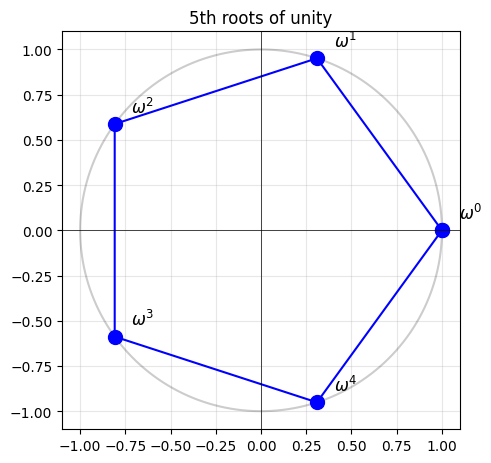

In [36]:
# Exercise 1.3.16 — Solution
n = 5
roots = [np.exp(2j * np.pi * k / n) for k in range(n)]

print(f"The {n}th roots of unity:")
for k, z in enumerate(roots):
    print(f"  ω^{k} = {z.real:.6f} + {z.imag:.6f}i")
    assert np.isclose(z**n, 1), f"Root {k} does not satisfy z^{n}=1"

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k-', alpha=0.2)

xs = [z.real for z in roots] + [roots[0].real]
ys = [z.imag for z in roots] + [roots[0].imag]
ax.plot(xs, ys, 'b-o', markersize=10)

for k, z in enumerate(roots):
    ax.annotate(f'$\\omega^{k}$', (z.real, z.imag),
               textcoords='offset points', xytext=(12, 8), fontsize=12)

ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('5th roots of unity')
ax.axhline(y=0, color='k', lw=0.5); ax.axvline(x=0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

**Exercise 1.3.17.** Verify that the sum of the $n$th roots of unity equals zero.

In [37]:
# Exercise 1.3.17 — Solution
# Sum of nth roots of unity = sum_{k=0}^{n-1} omega^k
# This is a geometric series: (omega^n - 1)/(omega - 1) = 0 since omega^n = 1.

for n in [3, 4, 5, 6, 10, 100]:
    roots = [np.exp(2j * np.pi * k / n) for k in range(n)]
    total = sum(roots)
    print(f"n={n:3d}: sum = {total.real:+.2e} + {total.imag:+.2e}i  (≈ 0)")

n=  3: sum = -2.22e-16 + +4.44e-16i  (≈ 0)
n=  4: sum = -1.84e-16 + +2.22e-16i  (≈ 0)
n=  5: sum = -1.11e-16 + +1.11e-16i  (≈ 0)
n=  6: sum = -2.22e-16 + +6.66e-16i  (≈ 0)
n= 10: sum = -3.33e-16 + +1.11e-16i  (≈ 0)
n=100: sum = -4.44e-15 + +5.43e-15i  (≈ 0)


**Exercise 1.3.18.** Write $z = 3 + 4i$ in exponential form $re^{i\theta}$.

In [38]:
# Exercise 1.3.18 — Solution
z = 3 + 4j
r = abs(z)
theta = cmath.phase(z)
print(f"z = 3 + 4i")
print(f"r = |z| = {r}")
print(f"θ = arg(z) = {theta:.6f} rad = {np.degrees(theta):.4f}°")
print(f"Exponential form: z = {r}·e^(i·{theta:.6f})")

# Verify
z_reconstructed = r * np.exp(1j * theta)
print(f"Verify: {z_reconstructed:.6f}")
print(f"Match: {np.isclose(z, z_reconstructed)}")

z = 3 + 4i
r = |z| = 5.0
θ = arg(z) = 0.927295 rad = 53.1301°
Exponential form: z = 5.0·e^(i·0.927295)
Verify: 3.000000+4.000000j
Match: True


**Exercise 1.3.19.** Consider the Mobius transformation $f(z) = \frac{z+1}{z-1}$. Compute $f(i)$.

In [39]:
# Exercise 1.3.19 — Solution
# f(z) = (z+1)/(z-1)
# f(i) = (i+1)/(i-1)
# Multiply numerator and denominator by conjugate of denominator:
# = (i+1)(-i-1) / ((i-1)(-i-1))
# Denominator: (i-1)(-i-1) = -i^2 -i +i +1 = 1+1 = 2
# Numerator: (i+1)(-i-1) = -i^2 -i -i -1 = 1 -2i -1 = -2i
# So f(i) = -2i / 2 = -i

z = 1j
result = (z + 1) / (z - 1)
print(f"f(i) = (i+1)/(i-1) = {result}")
print(f"= -i: {np.isclose(result, -1j)}")

# Also test a few more values
test_vals = [2+0j, 0+2j, -1+1j, 3+4j]
for z in test_vals:
    fz = (z + 1) / (z - 1)
    print(f"f({z}) = {fz:.4f}")

f(i) = (i+1)/(i-1) = (-0-1j)
= -i: True
f((2+0j)) = 3.0000+0.0000j
f(2j) = 0.6000-0.8000j
f((-1+1j)) = 0.2000-0.4000j
f((3+4j)) = 1.2000-0.4000j


## Summary

Complex numbers encode two degrees of freedom in a single algebraic object. The Cartesian form $z = a + bi$ makes addition transparent: just add the components. The polar form $z = re^{i\theta}$ makes multiplication transparent: multiply the magnitudes, add the angles.

This duality, switching between representations to use whichever makes the current problem simple, is a pattern that recurs throughout quantum computing. Quantum states are vectors with complex entries; quantum gates multiply those entries; interference is the cancellation (or reinforcement) that happens when complex amplitudes add. Everything in subsequent chapters rests on the fluency built here.